<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Rafael\AppData\Local\Temp\ipykernel_24356\3718249579.py:63: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title("Transformed Noise: $f(v) = \sin(25v) \cdot 0.5 + 0.5$")


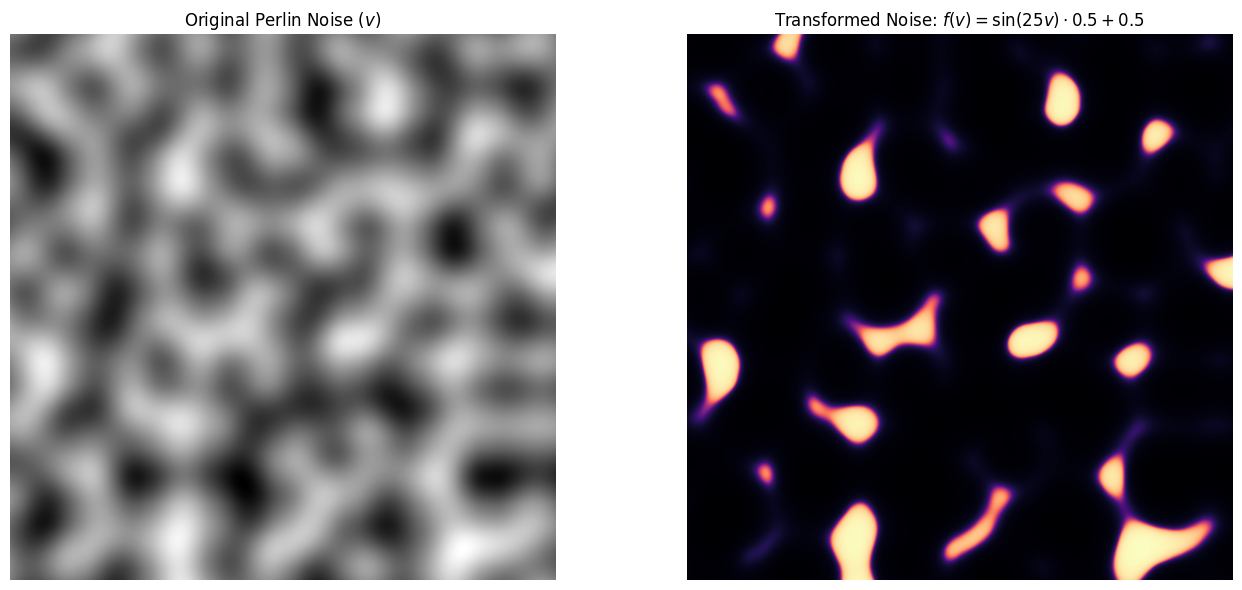

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def generate_perlin_noise_2d(shape, res):
    """
    Generates a 2D Perlin noise array.
    shape: (height, width) of the output image.
    res: (res_y, res_x) number of grid cells in each direction.
    """
    def fade(t):
        return 6*t**5 - 15*t**4 + 10*t**3

    delta = (res[0] / shape[0], res[1] / shape[1])
    d = (shape[0] // res[0], shape[1] // res[1])
    grid = np.mgrid[0:res[0]:delta[0], 0:res[1]:delta[1]].transpose(1, 2, 0) % 1
    
    # Create random gradients
    angles = 2 * np.pi * np.random.rand(res[0] + 1, res[1] + 1)
    gradients = np.dstack((np.cos(angles), np.sin(angles)))
    
    g00 = gradients[0:-1, 0:-1].repeat(d[0], 0).repeat(d[1], 1)
    g10 = gradients[1:, 0:-1].repeat(d[0], 0).repeat(d[1], 1)
    g01 = gradients[0:-1, 1:].repeat(d[0], 0).repeat(d[1], 1)
    g11 = gradients[1:, 1:].repeat(d[0], 0).repeat(d[1], 1)
    
    # Dot products with distance vectors
    n00 = np.sum(grid * g00, 2)
    n10 = np.sum(np.dstack((grid[:,:,0]-1, grid[:,:,1])) * g10, 2)
    n01 = np.sum(np.dstack((grid[:,:,0], grid[:,:,1]-1)) * g01, 2)
    n11 = np.sum(np.dstack((grid[:,:,0]-1, grid[:,:,1]-1)) * g11, 2)
    
    # Interpolation using the fade function
    t = fade(grid)
    n0 = n00 * (1 - t[:,:,0]) + t[:,:,0] * n10
    n1 = n01 * (1 - t[:,:,0]) + t[:,:,0] * n11
    return np.sqrt(2) * ((1 - t[:,:,1]) * n0 + t[:,:,1] * n1)

# 1. Generate Raw Perlin Noise
shape = (512, 512)
res = (8, 8)
noise = generate_perlin_noise_2d(shape, res)

# Normalize noise to range [0, 1]
noise = (noise - noise.min()) / (noise.max() - noise.min())

# 2. Define the Transformation Function f(v)
def transform_fn(v):
    # This example creates a striped/contoured effect
    return np.atan((v - 0.75)/0.02)*(1/np.pi + 0.01) + 0.5

transformed_noise = transform_fn(noise)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original Noise
axes[0].imshow(noise, cmap='gray', origin='lower')
axes[0].set_title("Original Perlin Noise ($v$)")
axes[0].axis('off')

# Transformed Noise
axes[1].imshow(transformed_noise, cmap='magma', origin='lower')
axes[1].set_title("Transformed Noise: $f(v) = \sin(25v) \cdot 0.5 + 0.5$")
axes[1].axis('off')

plt.tight_layout()
plt.show()